# Minimal Transformer: Next Token Prediction

In this notebook, we build a minimal decoder-only transformer architecture (similar to GPT) and train it on next token prediction. This follows your previous class on attention mechanisms.

**Key differences from encoder-decoder transformers:**
- Decoder-only architecture (no encoder)
- Causal self-attention (can only attend to previous tokens)
- Next token prediction objective
- Character-level tokenization for simplicity

## Setup

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import urllib.request
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.9.0+cu126


## Configuration

We keep the model small so it can train quickly in Colab.

In [16]:
# Model hyperparameters
class Config:
    # Model architecture
    d_model = 128          # Embedding dimension
    n_heads = 4            # Number of attention heads
    n_layers = 4           # Number of transformer blocks
    d_ff = 512             # Feed-forward dimension
    dropout = 0.1          # Dropout rate

    # Training
    block_size = 64        # Maximum context length
    batch_size = 64        # Batch size
    learning_rate = 3e-4   # Learning rate
    max_iters = 3000       # Training iterations
    eval_interval = 300    # Evaluate every N iterations
    eval_iters = 100       # Number of iterations for evaluation

config = Config()

## Data: Choose Your Dataset

Select one of the following datasets by uncommenting the corresponding option.

In [17]:
# ============================================================
# OPTION 1: TinyStories (Recommended - Modern, Simple English)
# ============================================================
# Download a subset of TinyStories dataset
# print("Downloading TinyStories dataset...")
# url = 'https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-train.txt'
# urllib.request.urlretrieve(url, 'dataset.txt')

# # Read only first ~1MB (similar to Shakespeare size)
# with open('dataset.txt', 'r', encoding='utf-8') as f:
#     text = f.read(1_000_000)  # Read first 1 million characters

# print(f'Dataset length: {len(text):,} characters')
# print(f'\nFirst 500 characters:')
# print(text[:500])

In [18]:
# ============================================================
# OPTION 2: Shakespeare (Classic - Early Modern English)
# ============================================================
# Uncomment these lines to use Shakespeare instead:

print("Downloading Shakespeare dataset...")
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve(url, 'dataset.txt')

with open('dataset.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f'Dataset length: {len(text):,} characters')
print(f'\nFirst 500 characters:')
print(text[:500])

Dataset length: 1,115,394 characters

First 500 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [19]:
# ============================================================
# OPTION 3: Python Code
# ============================================================
# Uncomment these lines to train on Python code:

# print("Downloading Python code dataset...")
# url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/linux/input.txt'
# urllib.request.urlretrieve(url, 'dataset.txt')
#
# with open('dataset.txt', 'r', encoding='utf-8') as f:
#     text = f.read(1_000_000)  # Read first 1 million characters
#
# print(f'Dataset length: {len(text):,} characters')
# print(f'\nFirst 500 characters:')
# print(text[:500])

In [20]:
# ============================================================
# OPTION 4: Modern Novel (e.g., The Adventures of Sherlock Holmes)
# ============================================================
# Uncomment these lines to use Sherlock Holmes:

# print("Downloading Sherlock Holmes...")
# url = 'https://www.gutenberg.org/files/1661/1661-0.txt'
# urllib.request.urlretrieve(url, 'dataset.txt')
#
# with open('dataset.txt', 'r', encoding='utf-8') as f:
#     text = f.read()
#
# # Remove Project Gutenberg header/footer
# start = text.find('I.')
# end = text.find('End of the Project Gutenberg')
# if start != -1 and end != -1:
#     text = text[start:end]
#
# print(f'Dataset length: {len(text):,} characters')
# print(f'\nFirst 500 characters:')
# print(text[:500])

In [21]:
# ============================================================
# OPTION 5: Wikipedia Article (Simple English Wikipedia)
# ============================================================
# Uncomment these lines to use Wikipedia:

# print("Downloading Wikipedia dump...")
# # This is a small subset of Simple English Wikipedia
# url = 'https://dumps.wikimedia.org/simplewiki/latest/simplewiki-latest-pages-articles.xml.bz2'
# # Note: This requires additional processing with packages like mwparserfromhell
# # For simplicity, you might want to manually download a few Wikipedia articles as .txt
# # Or use a pre-processed Wikipedia dataset
#
# # For a quick demo, here's a manual approach:
# text = """Wikipedia is a free online encyclopedia.
# [Paste several Wikipedia articles here as plain text]
# """
#
# print(f'Dataset length: {len(text):,} characters')

## Character-Level Tokenization

For simplicity, we use character-level tokenization. Each unique character becomes a token.

In [22]:
# Build vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f'Vocabulary size: {vocab_size} unique characters')
print(f'Characters: {"".join(chars)}')

# Create character-to-integer and integer-to-character mappings
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Encoder: string -> list of integers
def encode(s):
    return [char_to_idx[c] for c in s]

# Decoder: list of integers -> string
def decode(ids):
    return ''.join([idx_to_char[i] for i in ids])

# Test
test_str = "Hello, world!"
encoded = encode(test_str)
decoded = decode(encoded)
print(f'\nOriginal: {test_str}')
print(f'Encoded: {encoded}')
print(f'Decoded: {decoded}')

Vocabulary size: 65 unique characters
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Original: Hello, world!
Encoded: [20, 43, 50, 50, 53, 6, 1, 61, 53, 56, 50, 42, 2]
Decoded: Hello, world!


## Prepare Training Data

Split into train and validation sets.

In [23]:
# Encode the entire dataset
data = torch.tensor(encode(text), dtype=torch.long)
print(f'Encoded data shape: {data.shape}')

# Train/validation split (90/10)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f'Train data: {len(train_data):,} tokens')
print(f'Val data: {len(val_data):,} tokens')

Encoded data shape: torch.Size([1115394])
Train data: 1,003,854 tokens
Val data: 111,540 tokens


## Data Batching

Create batches of sequences for training. Each sequence is `block_size` tokens long.

In [24]:
def get_batch(split, config):
    """
    Generate a small batch of data of inputs x and targets y.

    Args:
        split: 'train' or 'val'
        config: Configuration object

    Returns:
        x: Input sequences [batch_size, block_size]
        y: Target sequences [batch_size, block_size]
    """
    data = train_data if split == 'train' else val_data

    # Randomly select starting positions
    ix = torch.randint(len(data) - config.block_size, (config.batch_size,))

    # Create input and target sequences
    x = torch.stack([data[i:i+config.block_size] for i in ix])
    y = torch.stack([data[i+1:i+config.block_size+1] for i in ix])

    x, y = x.to(device), y.to(device)
    return x, y

# Test batch generation
x_batch, y_batch = get_batch('train', config)
print(f'Input batch shape: {x_batch.shape}')
print(f'Target batch shape: {y_batch.shape}')
print(f'\nExample sequence:')
print(f'Input:  {decode(x_batch[0].tolist())}')
print(f'Target: {decode(y_batch[0].tolist())}')

Input batch shape: torch.Size([64, 64])
Target batch shape: torch.Size([64, 64])

Example sequence:
Input:  votion as yourselves,
To gratulate the gentle princes there.

QU
Target: otion as yourselves,
To gratulate the gentle princes there.

QUE


## Model Components

Now we build the transformer architecture from scratch.

### 1. Multi-Head Attention

You've already learned about attention! This is the causal (masked) version.

In [25]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head causal self-attention.

    Key difference from your previous class:
    - Uses a causal mask to prevent attending to future tokens
    """

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # Dimension per head

        # Linear projections for Q, K, V (all heads at once)
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)

        # Output projection
        self.W_o = nn.Linear(d_model, d_model, bias=True)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Args:
            x: Input tensor [batch_size, seq_len, d_model]

        Returns:
            Output tensor [batch_size, seq_len, d_model]
        """
        batch_size, seq_len, d_model = x.shape

        # Linear projections
        Q = self.W_q(x)  # [batch_size, seq_len, d_model]
        K = self.W_k(x)
        V = self.W_v(x)

        # Split into multiple heads and reshape
        # [batch_size, seq_len, d_model] -> [batch_size, seq_len, n_heads, d_k]
        # -> [batch_size, n_heads, seq_len, d_k]
        Q = Q.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)

        # Scaled dot-product attention
        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # [batch_size, n_heads, seq_len, seq_len]

        # Apply causal mask (prevent attending to future tokens)
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device)).bool()
        scores = scores.masked_fill(~mask, float('-inf'))

        # Apply softmax
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Apply attention to values
        out = torch.matmul(attn_weights, V)
        # [batch_size, n_heads, seq_len, d_k]

        # Concatenate heads
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)

        # Output projection
        out = self.W_o(out)

        return out

<div class='alert alert-info'>

Detalhe q pra **Q,K,V n usamos viés pq n tem mt interesse**, Q e K pq a atenção vai ser o quão esses dois são parecidos ent **n faz sentido poder deslocar os dois juntos**. Já pro valor, talvez seja interessante deslocar os **valores** além de só aumentar o diminuir multiplicando, mas isso já vai ser feito **na camada de saída q tem viés**, ent n é necessário em $W_V$ dado q n tem função de ativação entre a saída dela e a camada out. 

A função de ativação **Gelu é boa** pq zera os gradientes de ativações negativas o q **deixa esparso** (q nem ReLU, o q é mt útil o treinamento pq facilita pras GPUs) mas **n ignora pequenas ativações perto de zero**.

### 2. Feed-Forward Network

In [26]:
class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network.
    Two linear transformations with GELU activation.
    """

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

### 3. Transformer Block

Combines attention and feed-forward with residual connections and layer normalization.

In [27]:
class TransformerBlock(nn.Module):
    """
    A single transformer block:
    - Multi-head attention with residual connection
    - Feed-forward network with residual connection
    - Layer normalization (pre-norm architecture)
    """

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        # Pre-norm architecture (more stable training)
        # Attention with residual
        x = x + self.attn(self.ln1(x))
        # Feed-forward with residual
        x = x + self.ff(self.ln2(x))
        return x

### 4. Complete Transformer Model

In [28]:
class GPTModel(nn.Module):
    """
    A minimal GPT-style transformer for next token prediction.

    Architecture:
    1. Token embeddings + positional embeddings
    2. Stack of transformer blocks
    3. Layer norm
    4. Linear head to predict next token
    """

    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config

        # Token embeddings
        self.token_embedding = nn.Embedding(vocab_size, config.d_model)

        # Positional embeddings (learned)
        self.pos_embedding = nn.Embedding(config.block_size, config.d_model)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(config.d_model, config.n_heads, config.d_ff, config.dropout)
            for _ in range(config.n_layers)
        ])

        # Final layer norm
        self.ln_f = nn.LayerNorm(config.d_model)

        # Language modeling head
        self.lm_head = nn.Linear(config.d_model, vocab_size, bias=False)

        # Weight tying (share weights between token embeddings and lm_head)
        self.token_embedding.weight = self.lm_head.weight

        # Initialize weights
        self.apply(self._init_weights)

        # Report number of parameters
        n_params = sum(p.numel() for p in self.parameters())
        print(f"Number of parameters: {n_params/1e6:.2f}M")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        Args:
            idx: Input token indices [batch_size, seq_len]
            targets: Target token indices [batch_size, seq_len] (optional)

        Returns:
            logits: Output logits [batch_size, seq_len, vocab_size]
            loss: Cross-entropy loss (if targets provided)
        """
        batch_size, seq_len = idx.shape

        # Token embeddings
        tok_emb = self.token_embedding(idx)  # [batch_size, seq_len, d_model]

        # Positional embeddings
        pos = torch.arange(0, seq_len, dtype=torch.long, device=idx.device)
        pos_emb = self.pos_embedding(pos)  # [seq_len, d_model]

        # Add embeddings
        x = tok_emb + pos_emb  # Broadcasting happens automatically

        # Apply transformer blocks
        for block in self.blocks:
            x = block(x)

        # Final layer norm
        x = self.ln_f(x)

        # Language modeling head
        logits = self.lm_head(x)  # [batch_size, seq_len, vocab_size]

        # Compute loss if targets are provided
        loss = None
        if targets is not None:
            # Reshape for cross-entropy
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate new tokens autoregressively.

        Args:
            idx: Starting sequence [batch_size, seq_len]
            max_new_tokens: Number of tokens to generate
            temperature: Sampling temperature (higher = more random)
            top_k: If set, only sample from top k tokens

        Returns:
            Generated sequence [batch_size, seq_len + max_new_tokens]
        """
        for _ in range(max_new_tokens):
            # Crop context if needed (to fit block_size)
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]

            # Forward pass
            logits, _ = self(idx_cond)

            # Focus on last time step
            logits = logits[:, -1, :] / temperature  # [batch_size, vocab_size]

            # Optionally crop logits to only top k options
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')

            # Apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)

            # Append to sequence
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

## Create Model Instance

In [29]:
# Create model
model = GPTModel(vocab_size, config).to(device)

# Print model architecture
print(model)

Number of parameters: 0.81M
GPTModel(
  (token_embedding): Embedding(65, 128)
  (pos_embedding): Embedding(64, 128)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=False)
        (W_k): Linear(in_features=128, out_features=128, bias=False)
        (W_v): Linear(in_features=128, out_features=128, bias=False)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=512, out_features=128, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (ln_f): LayerNorm((128,)

## Training Setup

In [34]:
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

@torch.no_grad()
def estimate_loss(model, config):
    """
    Estimate loss on train and validation sets.
    """
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(config.eval_iters)
        for k in range(config.eval_iters):
            X, Y = get_batch(split, config)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## Test Generation Before Training

Let's see what the untrained model generates (should be gibberish).

In [14]:
# Generate from untrained model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=200, temperature=1.0, top_k=10)
print('\n=== Untrained Model Generation ===')
print(decode(generated[0].tolist()))
print('=' * 50)


=== Untrained Model Generation ===

SCt?CJU–FEEYKSmA?K||EQi||sEE|mM–jh’’jEbA?JiUtmP0MsgVKylTyY::jD00uP0sVVV1-wuGs9QDc00JDDPVVs!WOD,V!VsP1P!OssQiiiiK
sVvuVRpppVhhu!hsu1h
h“!DXM!U–VUWeOV11XDODVusOs!P!ODV–sPRV!!U!!Q!!0qs!DD–B!,sggD–O;Off0–


## Training Loop

Train for a few thousand iterations. Even this limited training should show improvement!

In [15]:
# Training loop
train_losses = []
val_losses = []
iterations = []

print('Starting training...')
print(f'Training for {config.max_iters} iterations')
print(f'Evaluating every {config.eval_interval} iterations\n')

for iter in tqdm(range(config.max_iters)):
    # Evaluate loss periodically
    if iter % config.eval_interval == 0 or iter == config.max_iters - 1:
        losses = estimate_loss(model, config)
        print(f"Step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        iterations.append(iter)

    # Sample a batch
    xb, yb = get_batch('train', config)

    # Forward pass
    logits, loss = model(xb, yb)

    # Backward pass
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print('\nTraining complete!')

Starting training...
Training for 3000 iterations
Evaluating every 300 iterations



  0%|          | 0/3000 [00:00<?, ?it/s]

Step 0: train loss 4.3986, val loss 4.3997
Step 300: train loss 2.0831, val loss 2.0896
Step 600: train loss 1.5855, val loss 1.5879
Step 900: train loss 1.3763, val loss 1.3839
Step 1200: train loss 1.2727, val loss 1.2799
Step 1500: train loss 1.1979, val loss 1.2258
Step 1800: train loss 1.1502, val loss 1.1810
Step 2100: train loss 1.1074, val loss 1.1426
Step 2400: train loss 1.0779, val loss 1.1108
Step 2700: train loss 1.0413, val loss 1.1000
Step 2999: train loss 1.0203, val loss 1.0806

Training complete!


## Plot Training Progress

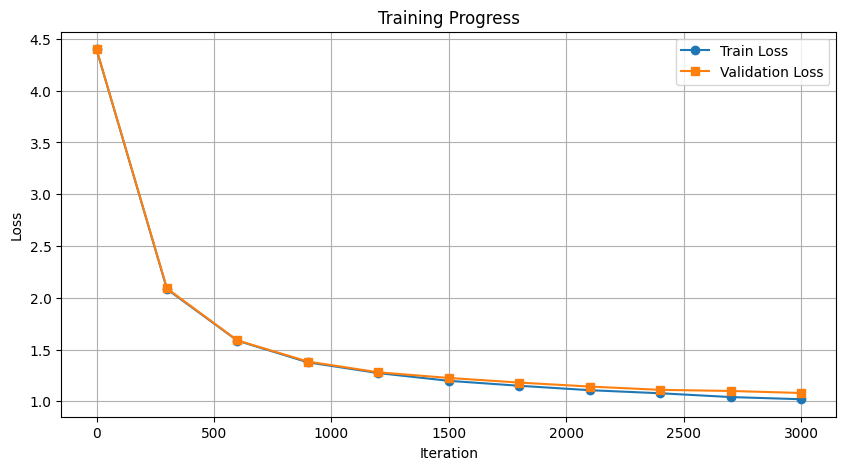

Initial train loss: 4.3986
Final train loss: 1.0203
Improvement: 3.3782


In [16]:
plt.figure(figsize=(10, 5))
plt.plot(iterations, train_losses, label='Train Loss', marker='o')
plt.plot(iterations, val_losses, label='Validation Loss', marker='s')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)
plt.show()

print(f'Initial train loss: {train_losses[0]:.4f}')
print(f'Final train loss: {train_losses[-1]:.4f}')
print(f'Improvement: {train_losses[0] - train_losses[-1]:.4f}')

## Test Generation After Training

Now let's see what the trained model generates!

In [17]:
# Generate from trained model
model.eval()
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=500, temperature=1.0, top_k=10)
print('\n=== Trained Model Generation ===')
print(decode(generated[0].tolist()))
print('=' * 50)


=== Trained Model Generation ===

Once upon a time, there was a lot of frog. The bird was their furte, and it for a grandme. The sill loved in and read about of and the mons. The more looking learned that it was very happy to be have too.
And they ropped to find a small trawin. They hugge, "Let's elp the moven clap to the page and passed whated arre to shot it.
Look through their friends and water okay. She were very tired something to much her friends some if them and around the big poop. He looked at her streach it started to 


<div class='alert alert-info'>

Note q ele pode ser meio merda, mas msm assim a gnt só botou letras no vocabulário dele, n falamos nada de inglês, ent ele já tá gerando palavras q ou são inglês ou parecem relativamente bem com a língua, o q é dahora já

## Generation with Different Seeds

Try starting with different prompts. Adjust these based on your dataset!

In [18]:
def generate_with_prompt(prompt, max_new_tokens=300, temperature=0.8, top_k=10):
    """
    Generate text starting from a prompt.
    """
    context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    generated = model.generate(context, max_new_tokens=max_new_tokens,
                             temperature=temperature, top_k=top_k)
    return decode(generated[0].tolist())

# Choose prompts based on your dataset:

# For TinyStories:
prompts = [
    "Once upon a time",
    "One day, a little",
    "There was a",
    "The girl was"
]

# For Shakespeare:
# prompts = [
#     "ROMEO:\n",
#     "To be or not to be",
#     "First Citizen:\n",
#     "The king"
# ]

# For Python code:
# prompts = [
#     "def ",
#     "import ",
#     "class ",
#     "for i in"
# ]

# For Sherlock Holmes:
# prompts = [
#     "Sherlock Holmes",
#     "The detective",
#     "Watson said",
#     "It was a"
# ]

for prompt in prompts:
    print(f'\n=== Prompt: "{prompt}" ===')
    generated_text = generate_with_prompt(prompt, max_new_tokens=200)
    print(generated_text)
    print('=' * 50)


=== Prompt: "Once upon a time" ===
Once upon a time, there was a friendly bag and cheery fish and was still asured.
<|endoftext|>
Once upon a time, there was a girl named Tom. He loved to play with her mom. They played to
<|endoftext|>

Once upon a ti

=== Prompt: "One day, a little" ===
One day, a little boy named Tim went to the park. They saw a big tree and came out. It was a big smile of cars and played with the bear and roll around and said, "No, I decided to make you safe, they decided to see th

=== Prompt: "There was a" ===
There was a little boy named Tim loved to play in the park. They were very pretty happy to play with the ball. They saw Sue and they were surprised and saw a big red hill. They all said, "That's a let!" Lily was

=== Prompt: "The girl was" ===
The girl was a cup too be man picket. The dog was very happy.
<|endoftext|>
Once upon a time, there was a party puddle dog named Amy was tired to reached. He was playing in the tree. Then, they are a grow friend.


## Temperature and Top-K Effects

Experiment with different generation parameters.

In [19]:
# Choose a prompt from your dataset:
prompt = "Once upon a time"  # For TinyStories
# prompt = "ROMEO:\n"  # For Shakespeare
# prompt = "def "  # For Python code
# prompt = "Sherlock Holmes"  # For Sherlock Holmes

print("=== Low Temperature (0.5) - More focused ===")
print(generate_with_prompt(prompt, max_new_tokens=150, temperature=0.5, top_k=10))

print("\n=== Medium Temperature (1.0) - Balanced ===")
print(generate_with_prompt(prompt, max_new_tokens=150, temperature=1.0, top_k=10))

print("\n=== High Temperature (1.5) - More random ===")
print(generate_with_prompt(prompt, max_new_tokens=150, temperature=1.5, top_k=10))

=== Low Temperature (0.5) - More focused ===
Once upon a time, there was a little boy named Tom. Tom was happy to see the strange was sad and said, "That's old many!" Sam said. "That's a special and put on the d

=== Medium Temperature (1.0) - Balanced ===
Once upon a time, there was a little buterflying named Tim. He came and he ponded trumpet to sumper. The string around from the ball. He took it and said, "I'm find m

=== High Temperature (1.5) - More random ===
Once upon a time, in a steer! Lucn's friendly happily, and she pused it in his sweet fox.
But then, Tone dishtacing, Spetted all dremised. I made you calked!"
The pas


## Analysis: What Did We Learn?

Even with this minimal training:
1. **Structure**: The model learns basic text structure (words, punctuation, capitalization)
2. **Patterns**: It picks up on common patterns in the data
   - TinyStories: narrative structure, character actions
   - Shakespeare: dialogue format, character names
   - Python code: syntax, indentation, function structure
3. **Context**: The causal attention allows it to use context from previous tokens
4. **Limitations**: It's not perfect - longer coherence requires much more training

**Key Architecture Points:**
- **Decoder-only**: Unlike encoder-decoder models for translation, this is decoder-only (like GPT)
- **Causal attention**: The mask ensures we only attend to past tokens
- **Next token prediction**: Simple but powerful objective
- **Scalability**: This same architecture scales to billions of parameters (GPT-3, GPT-4)

## Exercise

To improve this model further, try one or multiple of the following:
1. Train for more iterations (10k-50k)
2. Increase model size (more layers, larger d_model)
3. Combine datasets together to have more text (be careful of style differences)
4. Add learning rate scheduling
5. Modify the optimizer and hyperparameters
6. Implement gradient clipping
7. Try different tokenization (BPE instead of character-level)
8. Add dropout for better regularization
9. Experiment with different attention patterns (e.g., Flash Attention)

In [38]:
# Model hyperparameters
class Config:
    # Model architecture
    d_model = 256          # Embedding dimension
    n_heads = 8            # Number of attention heads
    n_layers = 16           # Number of transformer blocks
    d_ff = 512             # Feed-forward dimension
    dropout = 0.1          # Dropout rate

    # Training
    block_size = 64        # Maximum context length
    batch_size = 64        # Batch size
    learning_rate = 3e-4   # Learning rate
    max_iters = 10000       # Training iterations
    eval_interval = 400    # Evaluate every N iterations
    eval_iters = 100       # Number of iterations for evaluation

config = Config()

# Create model
model = GPTModel(vocab_size, config).to(device)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

Number of parameters: 8.45M


In [39]:
# Generate from untrained model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=200, temperature=1.0, top_k=10)
print('\n=== Untrained Model Generation ===')
print(decode(generated[0].tolist()))
print('=' * 50)


=== Untrained Model Generation ===

wa xtPBaPPPNBBBatkorkw owVtV&J
aK'attdd XKBlwr VlwPwVxxj 
d
PXXXSdhSBooxhxlPPwEaBrwqPwPrBPMqdggjqwqgJXooawooXj
Ga
ooBid&woKoxwKBxhax!XirBPXxnBMxtnBxFFdxMBMmmwoNxMdPPwoxPwXXtHrrewwwwaarwaXXBBgiirdS iX:


In [40]:
# Training loop
train_losses = []
val_losses = []
iterations = []

print('Starting training...')
print(f'Training for {config.max_iters} iterations')
print(f'Evaluating every {config.eval_interval} iterations\n')

for iter in tqdm(range(config.max_iters)):
    # Evaluate loss periodically
    if iter % config.eval_interval == 0 or iter == config.max_iters - 1:
        losses = estimate_loss(model, config)
        print(f"Step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        iterations.append(iter)

    # Sample a batch
    xb, yb = get_batch('train', config)

    # Forward pass
    logits, loss = model(xb, yb)

    # Backward pass
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print('\nTraining complete!')

Starting training...
Training for 10000 iterations
Evaluating every 400 iterations



  0%|          | 0/10000 [00:00<?, ?it/s]

Step 0: train loss 4.1402, val loss 4.1442
Step 400: train loss 2.2281, val loss 2.2507
Step 800: train loss 1.7626, val loss 1.8829
Step 1200: train loss 1.5687, val loss 1.7320
Step 1600: train loss 1.4654, val loss 1.6661
Step 2000: train loss 1.4048, val loss 1.6195
Step 2400: train loss 1.3615, val loss 1.5873
Step 2800: train loss 1.3256, val loss 1.5633
Step 3200: train loss 1.2988, val loss 1.5375
Step 3600: train loss 1.2690, val loss 1.5250
Step 4000: train loss 1.2486, val loss 1.5279
Step 4400: train loss 1.2228, val loss 1.5200
Step 4800: train loss 1.1994, val loss 1.5277
Step 5200: train loss 1.1775, val loss 1.5187
Step 5600: train loss 1.1569, val loss 1.5257
Step 6000: train loss 1.1301, val loss 1.5353
Step 6400: train loss 1.1151, val loss 1.5444
Step 6800: train loss 1.0846, val loss 1.5411
Step 7200: train loss 1.0648, val loss 1.5486
Step 7600: train loss 1.0463, val loss 1.5851
Step 8000: train loss 1.0228, val loss 1.5760
Step 8400: train loss 0.9984, val loss 

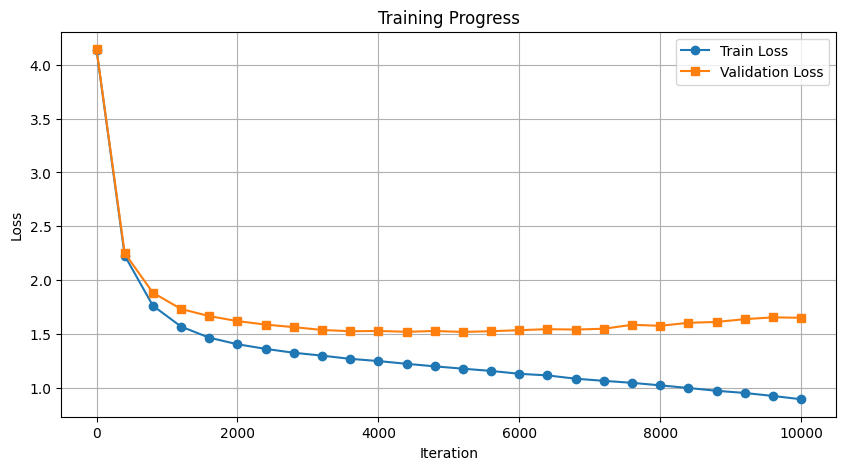

Initial train loss: 4.1402
Final train loss: 0.8940
Improvement: 3.2462


In [41]:
# Plot training progress
plt.figure(figsize=(10, 5))
plt.plot(iterations, train_losses, label='Train Loss', marker='o')
plt.plot(iterations, val_losses, label='Validation Loss', marker='s')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)
plt.show()

print(f'Initial train loss: {train_losses[0]:.4f}')
print(f'Final train loss: {train_losses[-1]:.4f}')
print(f'Improvement: {train_losses[0] - train_losses[-1]:.4f}')

In [42]:
# Generate from trained model
model.eval()
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=500, temperature=1.0, top_k=10)
print('\n=== Trained Model Generation ===')
print(decode(generated[0].tolist()))
print('=' * 50)


=== Trained Model Generation ===


FRIAR LAURENCE:
I do believe me: low are let in requit,
To hold my body's desire. But which calt him?

RATCLIFF:
Makes her corn, my lord; he comes, that lay the stand.

Nurse:
I am always like the sun.

GENTleman:
By my heart, how many appeared things it within.

Citizens:
No sir, not so.

VOLUMNIA:
They do bear her last retire, but that
I cannot was but but like a shamble slow,
I cannot tell: the gentler sheets have made along,
I'll make a sons. Thus, holy virtuous block
Stands sweet invocate,


In [43]:
def generate_with_prompt(prompt, max_new_tokens=300, temperature=0.8, top_k=10):
    """
    Generate text starting from a prompt.
    """
    context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    generated = model.generate(context, max_new_tokens=max_new_tokens,
                             temperature=temperature, top_k=top_k)
    return decode(generated[0].tolist())

# For Shakespeare:
prompts = [
    "ROMEO:\n",
    "To be or not to be",
    "First Citizen:\n",
    "The king"
]

for prompt in prompts:
    print(f'\n=== Prompt: "{prompt}" ===')
    generated_text = generate_with_prompt(prompt, max_new_tokens=200)
    print(generated_text)
    print('=' * 50)


=== Prompt: "ROMEO:
" ===
ROMEO:
No, it is ended.

Citizens:
Faith, Montague, I fear!

TRANIO:
Ay, sir; that's he was certain; 'twas pretty odds
March'd to the consent earth. Come all the heavens
To the man that select.

CAMILLO:
We 

=== Prompt: "To be or not to be" ===
To be or not to be too some force with grief words,
But as the servant of our behalfs do greeting,
Which now do so much lenity in the people,
As it were a prisoner of mortality:
But is my heart or a mourning witchcraft

=== Prompt: "First Citizen:
" ===
First Citizen:
Neighbours, we shall happed to him, besides, fiend
My knowledge plays to my heart.

FRIAR LAURENCE:
Ah, help, my lord, here bear you foot a common
Whom late's sending. I have broken a desperate spirit

=== Prompt: "The king" ===
The king's particular force.

LEONTES:
Where'er I wander?

LEONTES:
Be gone, good Paulina;
I will find you that all the prince's death?

CATESBY:
My lord, he hath sent you to him and you
To bear him to the be


## Save Model (Optional)

In [44]:
# Save model checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': config,
    'vocab_size': vocab_size,
    'char_to_idx': char_to_idx,
    'idx_to_char': idx_to_char,
}, 'shakespearean_minimal_transformer.pt')

print('Model saved to shakespearean_minimal_transformer.pt')

Model saved to shakespearean_minimal_transformer.pt


## Summary

In this notebook, we built a minimal transformer from scratch:
- Character-level tokenization
- Causal multi-head attention
- Position-wise feed-forward networks
- Residual connections and layer normalization
- Next token prediction training
- Autoregressive generation

This architecture is the foundation of modern LLMs like GPT!

**Questions to consider:**
1. Why is causal masking necessary for language generation?
2. What would happen without positional embeddings?
3. How does temperature affect generation quality?
4. What are the tradeoffs between character-level and subword tokenization?